In [106]:
from spline import cubic
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [107]:
# Generate some random points
x = torch.rand([5, 2], device=device) * 10
x_np = x.detach().cpu().numpy()
t_max = torch.tensor(4, device=device)
eval_t = torch.linspace(0, 4, 200, device=device)

## Natural Cubic Spline

In [108]:
natural_coeffs = cubic.solve_cubic_coeffs(t_max, x)
natural_spline = cubic.CubicSpline(natural_coeffs)
natural_trajectory = natural_spline.position(eval_t)
trajectory = natural_trajectory.detach().cpu().numpy()

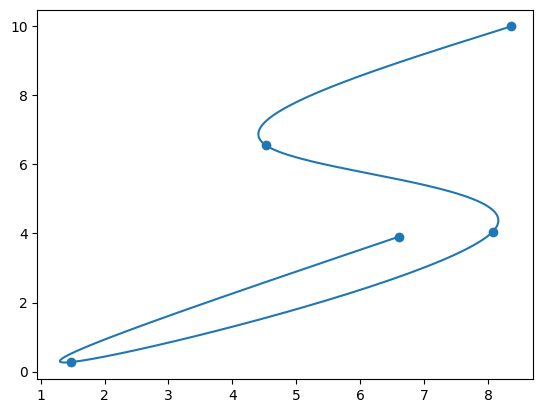

In [109]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])

Using different timings for the points for a non-uniform spline

In [110]:
t = torch.tensor([0., 0.5, 1., 3., 4.], device=device)
natural_coeffs = cubic.solve_cubic_coeffs(t, x)
natural_spline = cubic.CubicSpline(natural_coeffs)
natural_trajectory = natural_spline.position(eval_t)
trajectory = natural_trajectory.detach().cpu().numpy()

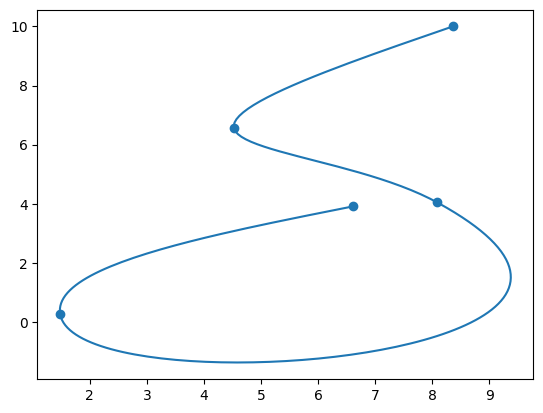

In [111]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])

## Clamped Cubic Spline

In [112]:
# Get to set the velocity of the spline at begin and end points
clamped_coeffs = cubic.solve_cubic_coeffs(t_max, x, end_condition=cubic.EndCondition.CLAMPED, v_begin=2., v_end=-4.)
clamped_spline = cubic.CubicSpline(clamped_coeffs)
clamped_trajectory = clamped_spline.position(eval_t)
trajectory = clamped_trajectory.detach().cpu().numpy()

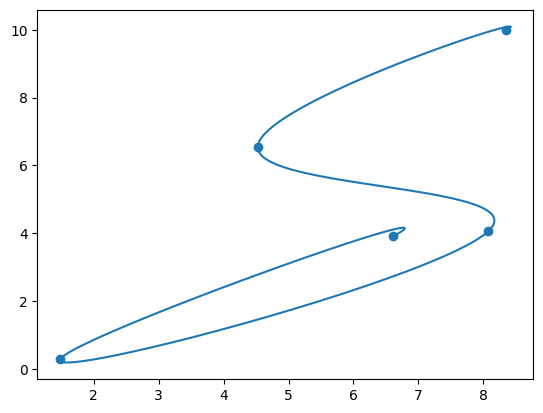

In [113]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])

Now using a different begin and end velocity

In [114]:
clamped_coeffs = cubic.solve_cubic_coeffs(t_max, x, end_condition=cubic.EndCondition.CLAMPED, v_begin=8., v_end=0.)
clamped_spline = cubic.CubicSpline(clamped_coeffs)
clamped_trajectory = clamped_spline.position(eval_t)
trajectory = clamped_trajectory.detach().cpu().numpy()

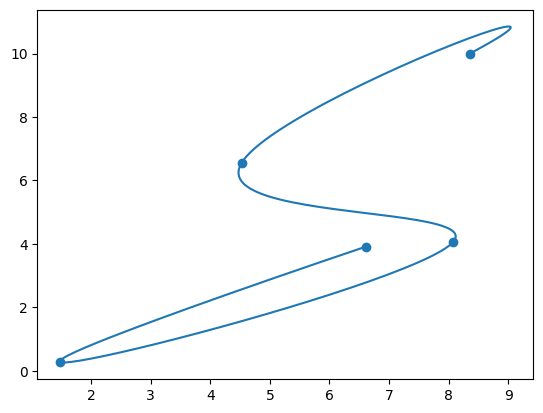

In [115]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])

## Closed Cubic Spline

In [116]:
# Need to append x_0 to the end of x again
# Note t needs one additional point relative to other methods which is the time connecting the last and first point
closed_t = torch.tensor([0., 0.5, 1., 3., 3.4, 4.], device=device)
closed_coeffs = cubic.solve_cubic_coeffs(closed_t, x, end_condition=cubic.EndCondition.CLOSED)
closed_spline = cubic.CubicSpline(closed_coeffs)
closed_trajectory = closed_spline.position(eval_t)
trajectory = closed_trajectory.detach().cpu().numpy()

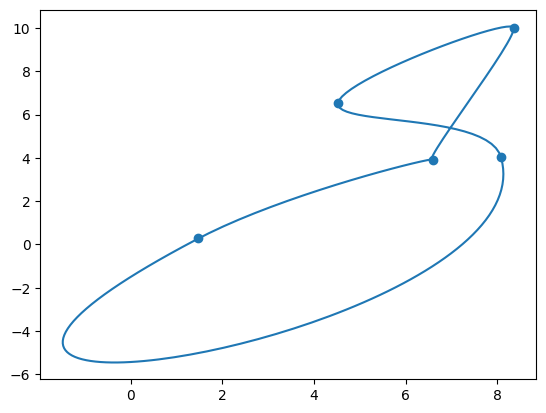

In [117]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])


## Lasso Cubic Spline

In [118]:
loop_index = 2
looping_coeffs = cubic.solve_cubic_coeffs(closed_t, x, end_condition=cubic.EndCondition.LOOPING, loop_index=loop_index)
looping_spline = cubic.CubicSpline(looping_coeffs, loop_index=loop_index)
looping_eval_t = torch.linspace(0, 50, 500, device=device)

looping_trajectory = looping_spline.position(eval_t)
looping_trajectory_long = looping_spline.position(looping_eval_t)
trajectory = looping_trajectory.detach().cpu().numpy()
trajectory_long = looping_trajectory_long.detach().cpu().numpy()


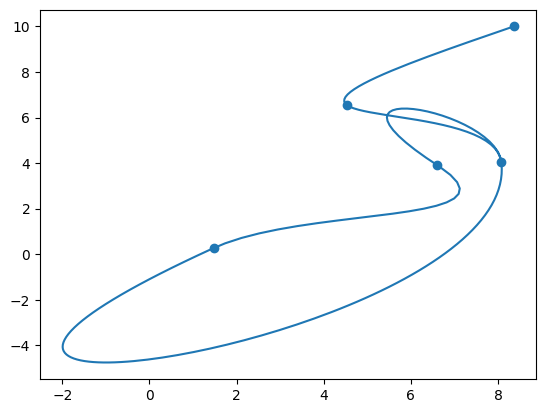

In [119]:
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])

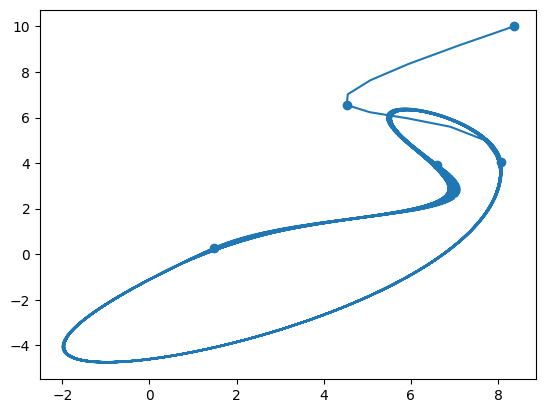

In [120]:
# Continue around the looping segment
plt.plot(trajectory_long[:, 0], trajectory_long[:, 1])
plt.scatter(x_np[:, 0], x_np[:, 1])